### Figure: Grid conductivity

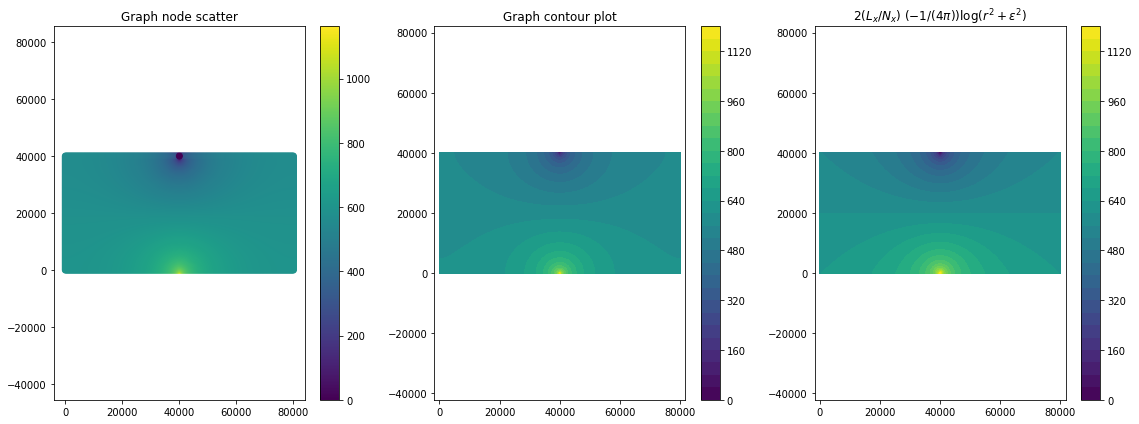

In [1]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import scipy.stats
import networkx as nx

import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import p_lithostatic, T_geothermal, MagmaChamber, GlobalSystemThreshold
import percolation_network

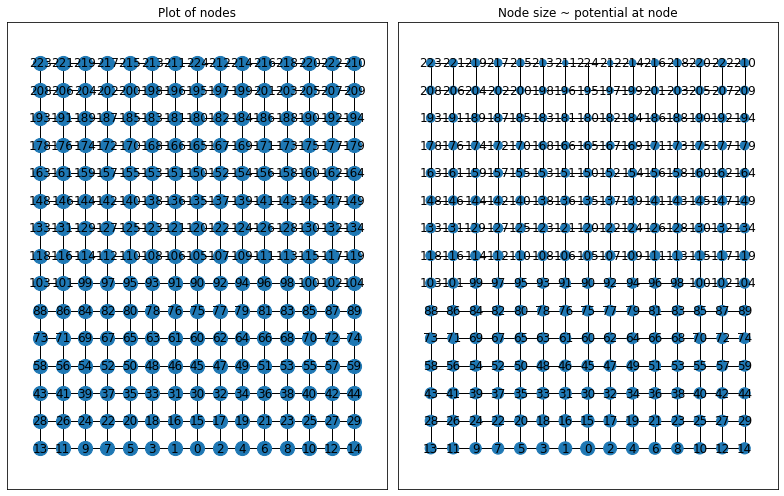

In [2]:
N_x = 15
N_z = 15
x_scale = 40e3
z_scale = 40e3
max_edge_dist = z_scale / (N_z-1) * 1.001
RG = percolation_network.RandomGraph(
  percolation_network.make_2D_grid_network(N_x, N_z, x_scale=x_scale, z_scale=z_scale,
                         R=500,
                         add_source_sink=False), max_edge_dist)

plt.figure(figsize=(11,7))

plt.subplot(1,2,1)
RG.draw_network()
plt.title("Plot of nodes")

plt.subplot(1,2,2)
v = RG.compute_st_potentials()
# plt.plot(v.squeeze())
length_scale = 1.0
nx.draw_networkx(RG.G, pos = {i:(n.x / length_scale, n.z / length_scale,)
                for (i, n) in enumerate(RG.node_list)}, node_size=(v - v.min())/30)
plt.title("Node size ~ potential at node")
plt.tight_layout()

Fix $N_z = 9$ layers in the vertical direction. As we vary $N_x$ (number of nodes in the horizontal direction), how does the effective conductivity change?

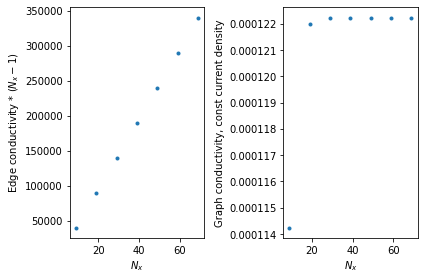

In [6]:
'''  '''
N_range = np.arange(9, 70, 10)
# N_range = np.array([23])
gc_range = np.zeros((len(N_range),))
ec_range = np.zeros((len(N_range),))

z_scale = 40e3

for i, N in enumerate(N_range):
  N_x = N
  N_z = 9
  x_scale = z_scale * (N_x-1) / (N_z-1)

  max_edge_dist = z_scale / (N_z-1) * 1.001
  RG = percolation_network.RandomGraph(
    percolation_network.make_2D_grid_network(N_x, N_z,
      x_scale=x_scale, z_scale=z_scale, R=500,
                          add_source_sink=False), max_edge_dist)
  gc_range[i] = RG.graph_conductivity()
  ec_range[i] = RG.edge_conductivity_list().max()

plt.subplot(1,2,1)
plt.plot(N_range, (N_range-1) / ec_range, '.')
plt.xlabel("$N_x$")
plt.ylabel("Edge conductivity * $(N_x-1)$")

plt.subplot(1,2,2)
plt.plot(N_range, gc_range, '.')
# plt.plot(N_range, gc_range / (N_range-1)**(1), '.')
plt.xlabel("$N_x$")
plt.ylabel("Graph conductivity, const current density")

plt.tight_layout()

''' Fixed (N_x-1) / (N_z-1), varying N_z '''
Fix $N_x = 2 N_z - 1$, i.e., constant aspect ratio of nodes in each direction. As we vary $N_x$, how does the effective conductivity change?

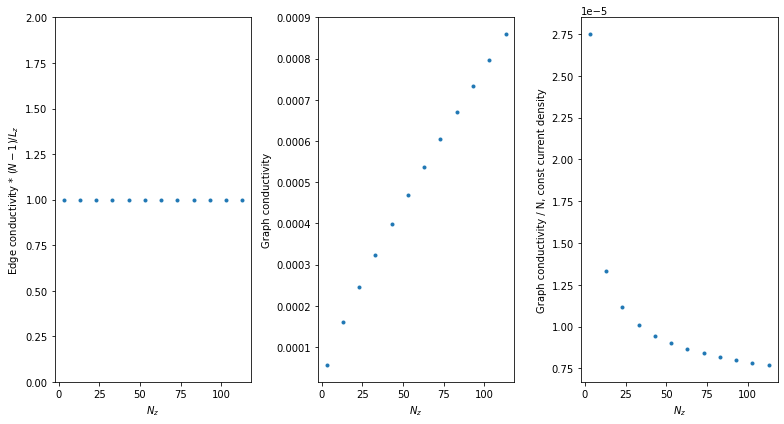

In [ ]:

# N_range = np.array([*np.arange(3, 15, 2), *np.arange(15, 56, 6)])
N_range = np.arange(3, 120, 10)
gc_range = np.zeros((len(N_range),))
ec_range = np.zeros((len(N_range),))

z_scale = 40e3

for i, N in enumerate(N_range):
  N_z = N
  N_x = 2*N - 1
  x_scale = z_scale * (N_x-1) / (N_z-1)

  # Set grid graph with lattice edges
  max_edge_dist = z_scale / (N_z-1) * 1.01
  RG = percolation_network.RandomGraph(
    percolation_network.make_2D_grid_network(N_x, N_z,
      x_scale=x_scale, z_scale=z_scale, R=500,
                          add_source_sink=False), max_edge_dist)
  gc_range[i] = RG.graph_conductivity()
  ec_range[i] = RG.edge_conductivity_list().max()

plt.figure(figsize=(11,6))

plt.subplot(1,3,1)
plt.plot(N_range, (N_range - 1) / ec_range / z_scale, '.')
plt.ylim(0, 2)
plt.xlabel("$N_z$")
plt.ylabel("Edge conductivity * $(N-1) / L_z$")

plt.subplot(1,3,2)
plt.plot(N_range, gc_range, '.')
plt.xlabel("$N_z$")
plt.ylabel("Graph conductivity")

plt.subplot(1,3,3)
plt.plot(N_range, gc_range / (N_range-1)**(1), '.')
plt.xlabel("$N_z$")
plt.ylabel("Graph conductivity / N, const current density")

plt.tight_layout()

Right: continuous log potential is singular; here regularized by replacing r^2 with r^2 + eps^2. 


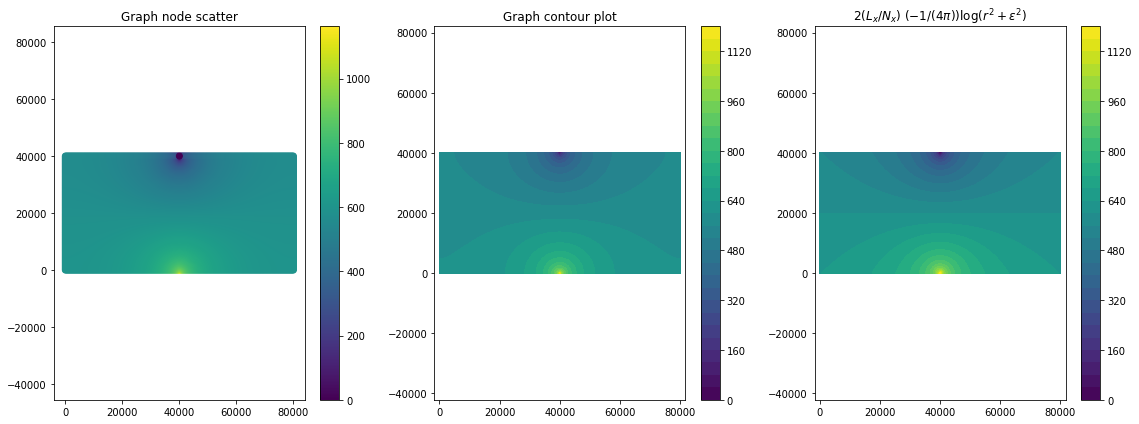

In [5]:
''' Plot graph potentials of last known graph `RG` '''

v = RG.compute_st_potentials()
v -= v.min()

plt.figure(figsize=(16,6))

plt.subplot(1,3,1)
plt.scatter([n.x / length_scale for (i, n) in enumerate(RG.node_list)],
            [n.z / length_scale for (i, n) in enumerate(RG.node_list)],
            c=v)
plt.colorbar()
plt.title("Graph node scatter")
plt.axis("equal")
# Reconstruct node coordinates as array
coords = np.array([[n.x, n.z] for (i, n) in enumerate(RG.node_list)])
ind = np.lexsort(coords.T)
v_flat = v[ind]
x_flat, z_flat = coords[ind,:].T
mg_x = np.reshape(x_flat, (N_z, N_x))
mg_z = np.reshape(z_flat, (N_z, N_x))
mg_v = np.reshape(v_flat, (N_z, N_x))

plt.subplot(1,3,2)
plt.contourf(mg_x, mg_z, mg_v, levels=30)
plt.colorbar()
plt.title("Graph contour plot")
plt.axis("equal")

eps = x_scale / N_x * 1e-14
Gs = -1/(4*np.pi) * np.log((mg_x - 0.5*x_scale)**2 + mg_z**2 + eps*eps)
Gt = 1/(4*np.pi) * np.log((mg_x - 0.5*x_scale)**2 + (mg_z-z_scale)**2 + eps*eps)
rs = np.sqrt((mg_x - 0.5*x_scale)**2 + (mg_z)**2)
rt = np.sqrt((mg_x - 0.5*x_scale)**2 + (mg_z-z_scale)**2)

analog_potential = 2 * (x_scale / N_x) * (Gs + Gt)
# dGdy = 1/(2*np.pi) / rs * (mg_z / rs)
plt.subplot(1,3,3)
plt.contourf(mg_x, mg_z, np.clip(analog_potential, -600, 600)+600, levels=30)
# plt.contourf(mg_x, mg_z, dGdy, levels=30)
plt.colorbar()
plt.title(r"$2 (L_x / N_x)~(-1/(4\pi))\log(r^2 + \epsilon^2)$")
plt.axis("equal")

plt.tight_layout()
print("Right: continuous log potential is singular; here regularized by replacing r^2 with r^2 + eps^2. ")

The regular grid graph potentials (left two panels) approach the continuum Laplacian solution for a specific set of boundary conditions. That is,
$$
- \nabla^2 p = 0
$$
where
$\frac{\partial p}{\partial n} = 0$
on the boundary, except for an interval $(-\epsilon, \epsilon)$ on the top and bottom boundaries, where the current is prescribed.

The analytic solution is dependent on $\epsilon$, and as $\epsilon \to 0$, the potential becomes singular.